# Altitude vs Time — Pressure Altimeter
Plot barometric (pressure) altitude AGL from the low-rate Blue Raven data.

In [2]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

import pandas as pd
import matplotlib.pyplot as plt
from path_config import default_lr_csv

# Load the low-rate CSV (contains barometric altitude)
lr_path = default_lr_csv()
df = pd.read_csv(lr_path, skipinitialspace=True)

# Strip whitespace from column names
df.columns = df.columns.str.strip()

print("LR CSV:", lr_path.name)
print("Columns:", list(df.columns))

LR CSV: SnowbirdPrim LR_03-21-2026_10_52_17.csv
Columns: ['Year', 'Month', 'Day', 'Time', 'Flight_Time_(s)', 'Sync', 'Temperature_(F)', 'Baro_Press_(atm)', 'Baro_Altitude_ASL_(feet)', 'Baro_Altitude_AGL_(feet)', 'Batt_Volts', 'Apo_Volts', 'Main_Volts', '3rd_Volts', '4th_Volts', 'Velocity_Up', 'Velocity_DR', 'Velocity_CR', 'Inertial_Altitude', 'Inertial_DR_Position', 'Inertial_CR_position', 'Tilt_Angle_(deg)', 'Future_Angle_(deg)', 'Roll_Angle_(deg)', 'Reserved_1', 'Reserved_2', 'Reserved_3', 'Rocket_FER_Hex', 'Apo_FER_H  ex', 'Main_FER_Hex', '3rd_FER_Hex', '4th_FER_Hex', 'Liftoff', 'Apogee', 'Press_Increasing', 'Burnout_Coast', 'Apo_fired', 'Main_fired', '3rd_fired', '4th_fired', 'Normal_Ascent', 'Accel_Vel_LE_0', 'ECI_Vvel_le_0', 'Tilt Exceeded 90deg', 'Reserved', 'LT_AGL1', 'GT_AGL2', 'LT_FANG1', 'GT_FANG2', 'GT_FUTANG', 'LT_TVAL1', 'GT_TVAL2', 'LT_VEL1', 'GT_VEL2', 'LT_BVEL1', 'GT_BURN', 'Armed', 'Reserved.1', 'Reserved.2', 'LT_AGL1.1', 'GT_AGL2.1', 'LT_FANG1.1', 'GT_FANG2.1', 'GT_F

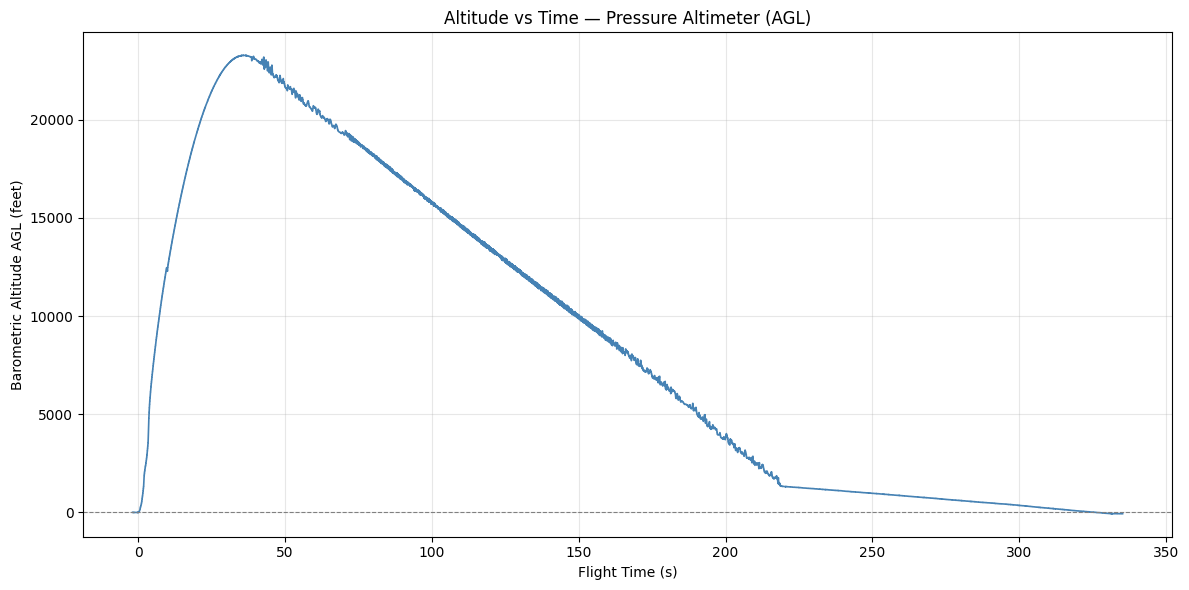

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df["Flight_Time_(s)"], df["Baro_Altitude_AGL_(feet)"], linewidth=1.2, color="steelblue")

ax.set_xlabel("Flight Time (s)")
ax.set_ylabel("Barometric Altitude AGL (feet)")
ax.set_title("Altitude vs Time — Pressure Altimeter (AGL)")
ax.grid(True, alpha=0.3)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")

plt.tight_layout()
plt.show()

In [4]:
apogee_idx = df["Baro_Altitude_AGL_(feet)"].idxmax()
apogee_time = df.loc[apogee_idx, "Flight_Time_(s)"]
apogee_alt = df.loc[apogee_idx, "Baro_Altitude_AGL_(feet)"]

print(f"Time to apogee: {apogee_time:.2f} s")
print(f"Apogee altitude (AGL): {apogee_alt:.1f} feet")

Time to apogee: 36.54 s
Apogee altitude (AGL): 23276.0 feet
